# Optimise model

Run grid search with cross-validation for hyperparameter optimisation

In [1]:
run = "k"

In [8]:
import sys
sys.path.append("../../../src/ml")

In [6]:
!pwd

/home/sgrant/mu2e-cosmic/notebooks/ml/xgboost


In [9]:
from assemble import AssembleDataset
assembler = AssembleDataset(run=run, cutset_name="MLPreprocess", verbosity=2)
data = assembler.assemble_dataset()

[LoadML] [OK] Initialised
[Load] [OK] Initialised with out_path=/home/sgrant/mu2e-cosmic/output/ml/k/data/CRY_onspill-LH_aw
[Load] [OK] Successfully loaded results from /home/sgrant/mu2e-cosmic/output/ml/k/data/CRY_onspill-LH_aw/results.pkl
[Load] [OK] Initialised with out_path=/home/sgrant/mu2e-cosmic/output/ml/k/data/CE_mix2BB_onspill-LH_aw
[Load] [OK] Successfully loaded results from /home/sgrant/mu2e-cosmic/output/ml/k/data/CE_mix2BB_onspill-LH_aw/results.pkl
[LoadML] [OK] Got full results
[Assemble] [OK] Loaded data
[Assemble] [OK] Initialised
[Assemble] [DEBUG] Got sorted and labelled DataFrames
[Assemble] [DEBUG] Got combined dataset
[Assemble] [DEBUG] Columns: Index(['event', 'subrun', 'crv_x', 'crv_y', 'crv_z', 'PEs', 'dT', 'nHits',
       'nLayers', 'angle', 'timeStart', 'timeEnd', 'sector', 'PEs_per_hit',
       't0', 'd0', 'tanDip', 'maxr', 'mom_mag', 'label'],
      dtype='str')
[Assemble] [OK] Split data 70/15/15 (event-level grouping)
  Train: 1515614 coincidences
  Val:

In [10]:
from optimise import Optimise
opt = Optimise(data, run=run, min_efficiency=0.999, scale_features=False)

param_grid = {
    "n_estimators": [100, 200, 500, 1000],
    "max_depth": [3, 5, 7, 9],
    "learning_rate": [0.05, 0.1, 0.3],
}

best = opt.grid_search_cv(param_grid, n_folds=5, fixed_params = {"device": "cuda", "tree_method": "hist"})

[Optimise] [OK] Initialised
[Optimise] [INFO] CV grid search: 48 combinations x 5 folds = 240 fits over ['n_estimators', 'max_depth', 'learning_rate']
[Optimise] [INFO] [1/48] scan_cv_000: deadtime=7.505±2.504%, veto_eff=99.929%, overfit_gap=0.00004
[Optimise] [INFO] [2/48] scan_cv_001: deadtime=0.836±0.099%, veto_eff=99.929%, overfit_gap=0.00004
[Optimise] [INFO] [3/48] scan_cv_002: deadtime=0.183±0.047%, veto_eff=99.929%, overfit_gap=0.00007
[Optimise] [INFO] [4/48] scan_cv_003: deadtime=4.201±5.213%, veto_eff=99.929%, overfit_gap=0.00020
[Optimise] [INFO] [5/48] scan_cv_004: deadtime=0.393±0.186%, veto_eff=99.929%, overfit_gap=0.00007
[Optimise] [INFO] [6/48] scan_cv_005: deadtime=0.277±0.165%, veto_eff=99.929%, overfit_gap=0.00011
[Optimise] [INFO] [7/48] scan_cv_006: deadtime=0.992±0.736%, veto_eff=99.929%, overfit_gap=0.00017
[Optimise] [INFO] [8/48] scan_cv_007: deadtime=0.253±0.111%, veto_eff=99.929%, overfit_gap=0.00007
[Optimise] [INFO] [9/48] scan_cv_008: deadtime=0.147±0.03

[Optimise] [OK] Saved to /home/sgrant/mu2e-cosmic/output/images/ml/k/optimise/overfit_max_depth.png


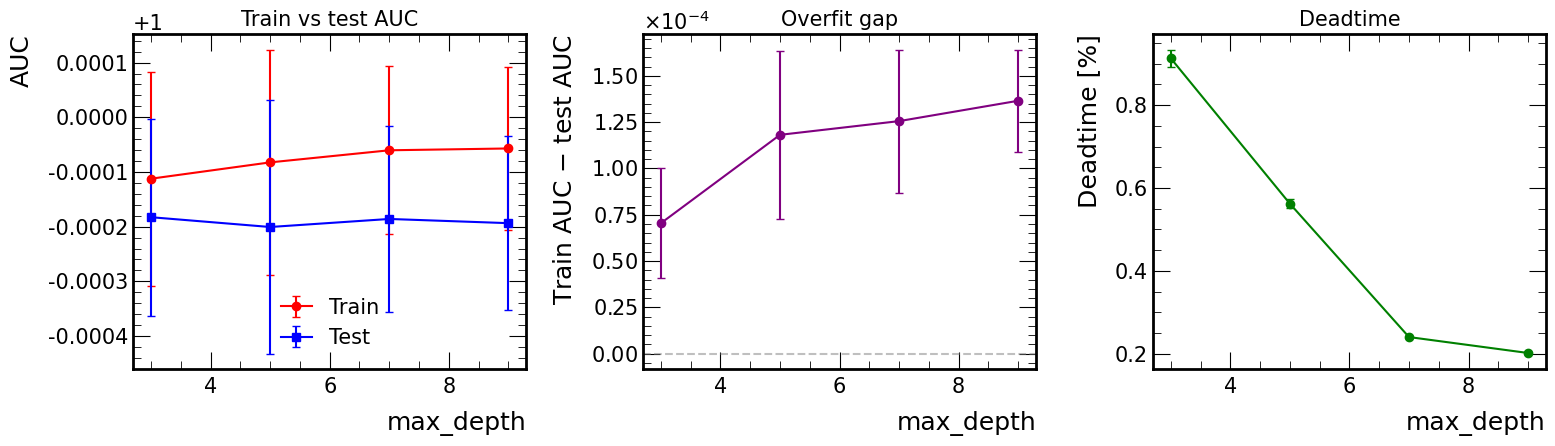

[Optimise] [OK] Saved to /home/sgrant/mu2e-cosmic/output/images/ml/k/optimise/overfit_n_estimators.png


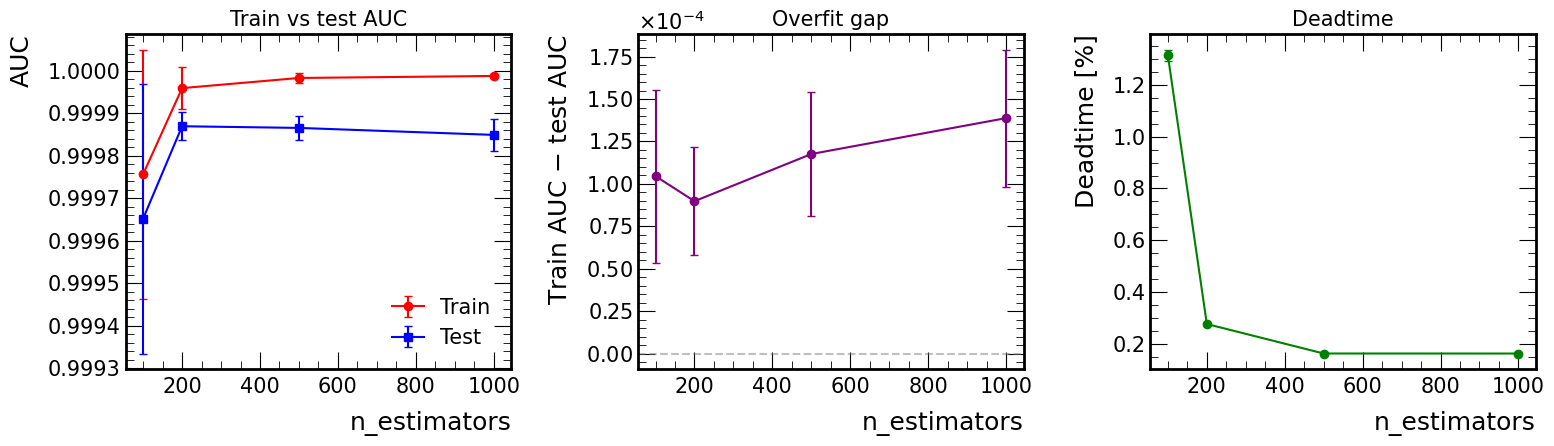

[Optimise] [OK] Saved to /home/sgrant/mu2e-cosmic/output/images/ml/k/optimise/overfit_learning_rate.png


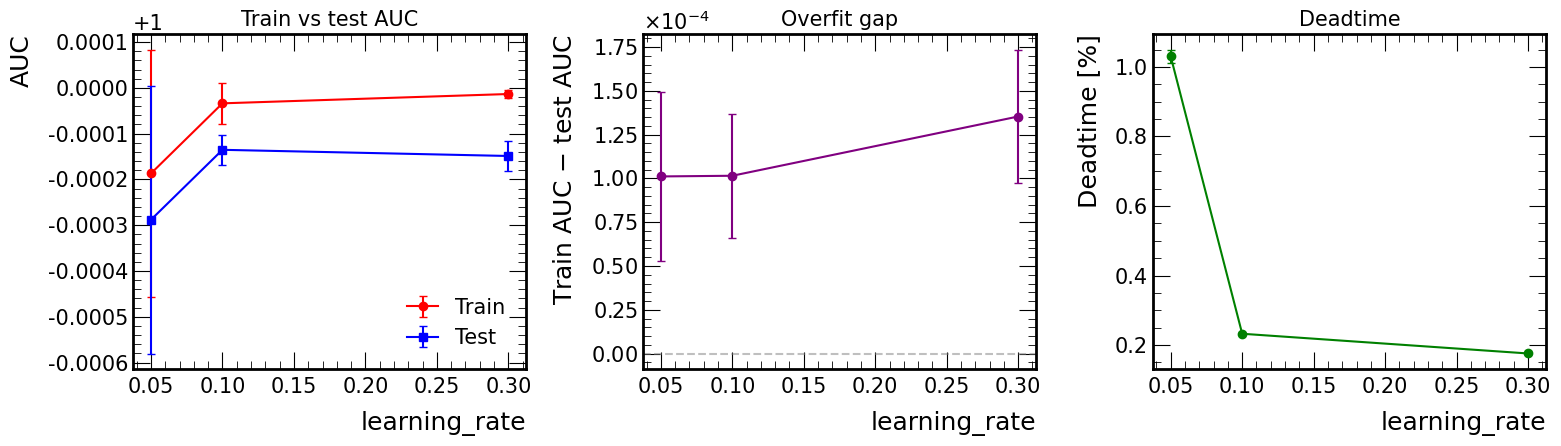

[Optimise] [OK] Summary saved to /home/sgrant/mu2e-cosmic/output/ml/k/results/optimisation_summary.csv


In [11]:
opt.plot_overfit_diagnostic("max_depth")
opt.plot_overfit_diagnostic("n_estimators")
opt.plot_overfit_diagnostic("learning_rate")

opt.save_summary()

In [21]:
opt.get_summary()

,tag,n_estimators,max_depth,learning_rate,train_auc,test_auc,overfit_gap,threshold,veto_efficiency,veto_efficiency_std,deadtime,deadtime_std,signal_efficiency
0,scan_cv_034,500,9,0.10,0.999990,0.999855,0.000135,0.037664,0.999286,0.000003,0.001260,0.000377,0.998740
1,scan_cv_022,200,9,0.10,0.999986,0.999861,0.000125,0.060846,0.999286,0.000003,0.001334,0.000479,0.998666
2,scan_cv_043,1000,7,0.10,0.999990,0.999835,0.000156,0.032603,0.999286,0.000003,0.001418,0.000549,0.998582
3,scan_cv_036,1000,3,0.05,0.999973,0.999901,0.000072,0.115732,0.999286,0.000003,0.001425,0.000274,0.998575
4,scan_cv_032,500,7,0.30,0.999991,0.999828,0.000163,0.019222,0.999286,0.000003,0.001430,0.000552,0.998570
5,scan_cv_046,1000,9,0.10,0.999990,0.999832,0.000159,0.021722,0.999286,0.000003,0.001440,0.000500,0.998560
6,scan_cv_008,100,7,0.30,0.999987,0.999881,0.000106,0.037564,0.999286,0.000003,0.001467,0.000368,0.998533
7,scan_cv_033,500,9,0.05,0.999987,0.999861,0.000127,0.043424,0.999286,0.000003,0.001479,0.000753,0.998521
8,scan_cv_031,500,7,0.10,0.999989,0.999858,0.000131,0.042644,0.999286,0.000003,0.001482,0.000646,0.998518
9,scan_cv_011,100,9,0.30,0.999989,0.999874,0.000115,0.037844,0.999286,0.000003,0.001497,0.000573,0.998503


In [22]:
# # !cat /home/sgrant/mu2e-cosmic/output/ml/k/results/optimisation_summary.csv
# import pandas as pd
# display(pd.DataFrame(best))best.keys()

The top ~20 hyperparameter combinations are statistically indistinguishable in deadtime (0.13–0.17%, with fold-to-fold std ~0.05–0.1%). The marginal plots show clear plateaus beyond max_depth=7, n_estimators=200, and learning_rate=0.1, with no meaningful gain from increased complexity. This combination has a low overfit gap (0.000087), confirming the model generalises well. Deeper trees or more estimators increase model complexity and inference time without measurable improvement in veto efficiency or deadtime.

## Class imbalance 

In [23]:
data["y_train"].value_counts()

label
0    1499004
1      16610
Name: count, dtype: int64

In [24]:
param_grid = {
    "scale_pos_weight": [1, 10, 50, 90],
}
best = opt.grid_search_cv(param_grid, n_folds=5, fixed_params = {"max_depth": 7, "n_estimators": 200, "learning_rate": 0.1, "device": "cuda", "tree_method": "hist"})


[Optimise] [INFO] CV grid search: 4 combinations x 5 folds = 20 fits over ['scale_pos_weight']
[Optimise] [INFO] [1/4] scan_cv_000: deadtime=0.169±0.101%, veto_eff=99.929%, overfit_gap=0.00009
[Optimise] [INFO] [2/4] scan_cv_001: deadtime=0.145±0.066%, veto_eff=99.929%, overfit_gap=0.00014
[Optimise] [INFO] [3/4] scan_cv_002: deadtime=0.173±0.159%, veto_eff=99.929%, overfit_gap=0.00017
[Optimise] [INFO] [4/4] scan_cv_003: deadtime=0.148±0.107%, veto_eff=99.929%, overfit_gap=0.00019
[Optimise] [OK] CV grid search complete. Best: scan_cv_001 (deadtime: 0.145%, veto eff: 99.929%)


[Optimise] [OK] Saved to /home/sgrant/mu2e-cosmic/output/images/ml/k/optimise/overfit_scale_pos_weight.png


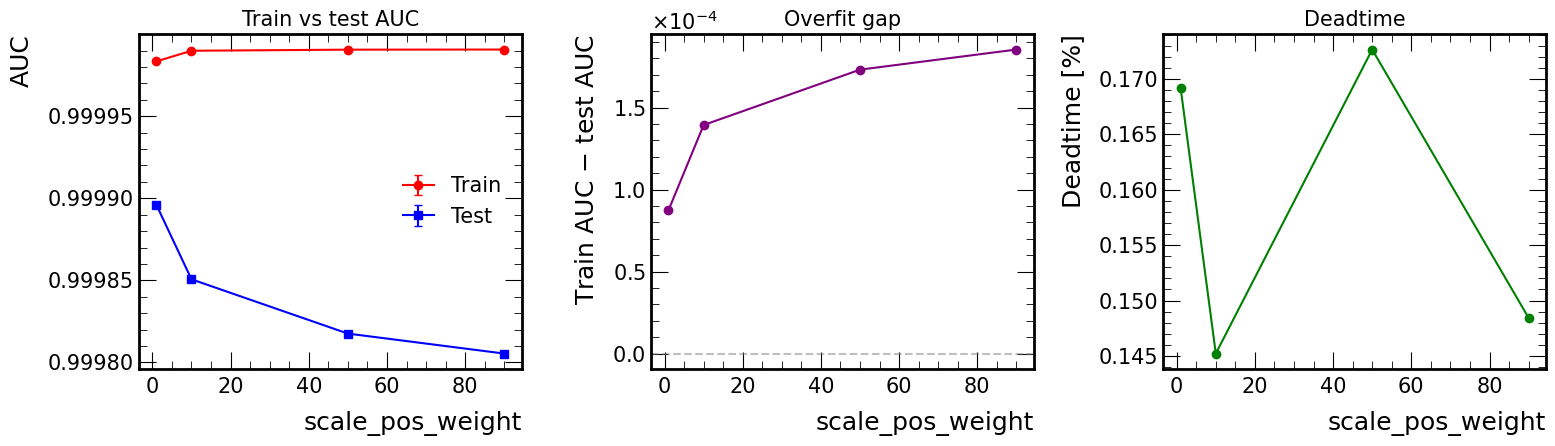

In [26]:
opt.plot_overfit_diagnostic("scale_pos_weight")

In [25]:
opt.get_summary()

,tag,n_estimators,max_depth,learning_rate,train_auc,test_auc,overfit_gap,threshold,veto_efficiency,veto_efficiency_std,deadtime,deadtime_std,signal_efficiency,scale_pos_weight
0,scan_cv_034,500.0,9.0,0.10,0.999990,0.999855,0.000135,0.037664,0.999286,0.000003,0.001260,0.000377,0.998740,NaN
1,scan_cv_022,200.0,9.0,0.10,0.999986,0.999861,0.000125,0.060846,0.999286,0.000003,0.001334,0.000479,0.998666,NaN
2,scan_cv_043,1000.0,7.0,0.10,0.999990,0.999835,0.000156,0.032603,0.999286,0.000003,0.001418,0.000549,0.998582,NaN
3,scan_cv_036,1000.0,3.0,0.05,0.999973,0.999901,0.000072,0.115732,0.999286,0.000003,0.001425,0.000274,0.998575,NaN
4,scan_cv_032,500.0,7.0,0.30,0.999991,0.999828,0.000163,0.019222,0.999286,0.000003,0.001430,0.000552,0.998570,NaN
5,scan_cv_046,1000.0,9.0,0.10,0.999990,0.999832,0.000159,0.021722,0.999286,0.000003,0.001440,0.000500,0.998560,NaN
6,scan_cv_001,NaN,NaN,NaN,0.999990,0.999851,0.000139,0.206701,0.999286,0.000003,0.001452,0.000658,0.998548,10.0
7,scan_cv_008,100.0,7.0,0.30,0.999987,0.999881,0.000106,0.037564,0.999286,0.000003,0.001467,0.000368,0.998533,NaN
8,scan_cv_033,500.0,9.0,0.05,0.999987,0.999861,0.000127,0.043424,0.999286,0.000003,0.001479,0.000753,0.998521,NaN
9,scan_cv_031,500.0,7.0,0.10,0.999989,0.999858,0.000131,0.042644,0.999286,0.000003,0.001482,0.000646,0.998518,NaN
